# Integrating all ULMS samples for the revision
- Inputs: all preprocessed samples after QC and doublet removal
- Initial model (before RBC and low-quality cluster removal)

In [1]:
import os
import sys
import numpy as np
import scanpy as sc
import torch
import scvi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import anndata as ad
from pathlib import Path
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
mpl.rcParams['ps.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator

module_path = '/labs/delitto/james/functions/'
sys.path.append(module_path)
import jpascvi

In [2]:
torch.cuda.is_available()

True

In [3]:
# version control
print("seaborn:", sns.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scanpy:", sc.__version__)
print("scvi:", scvi.__version__)
scvi.settings.seed = 1234
sns.set_theme()
torch.set_float32_matmul_precision("high")

[rank: 0] Seed set to 1234


seaborn: 0.13.2
pandas: 2.2.2
numpy: 1.26.4
scanpy: 1.10.2
scvi: 1.1.6


In [4]:
# Set up input and output directories
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent
print(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / 'preprocessed'
print(DATA_DIR)

output_dir = jpascvi.create_output_dir(PROJECT_DIR, 'scvi_low_quality', change_dir=True)

/oak/stanford/groups/longaker/ULMS/revision/scRNAseq
/oak/stanford/groups/longaker/ULMS/revision/scRNAseq/preprocessed
Created output directory /oak/stanford/groups/longaker/ULMS/revision/scRNAseq/scvi_low_quality
Default output directory changed to /oak/stanford/groups/longaker/ULMS/revision/scRNAseq/scvi_low_quality


# Load, concatenate, and prepare anndata for scVI

In [5]:
# load preprocessed anndatas
adata_list = jpascvi.import_data(DATA_DIR)
adata_list.sort(key=lambda x: np.unique(x.uns['filename']))

for adata in adata_list:
    print(list(np.unique(adata.obs['batch'])))
    print(list(np.unique(adata.obs['sample'])))
    print(adata.uns['filename'])
    print(adata)
    print()  

['Batch01']
['Sample02', 'Sample03', 'Sample04']
Batch01_cb_feature_bc_matrix_filtered.h5
AnnData object with n_obs × n_vars = 11925 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'batch', 'filename'

['Batch02']
['Sample02']
Batch02_cb_feature_bc_matrix_filtered.h5
AnnData object with n_obs × n_vars = 19588 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total

In [6]:
len(adata_list)

23

In [7]:
# concatenate the samples
adata = ad.concat(adata_list, join="inner")
del adata_list
adata

AnnData object with n_obs × n_vars = 239879 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score'

In [9]:
# Make a raw counts object of concatenated preprocessed anndatas
os.mkdir(PROJECT_DIR / 'objects')
adata.write_h5ad('objects/ulms_raw.h5ad')

In [ ]:
adata.layers["counts"] = adata.X.copy() # this layer will contain the raw counts
sc.pp.normalize_total(adata) # normalize X to the median total counts
sc.pp.log1p(adata) # logarithmize X
adata.raw = adata # full dimension normalized logtransformed raw data

In [ ]:
# Calculate HVGs. We use 2000 per the Zappia et al feature selection paper
print(f"Number of genes before HVG selection: {adata.n_vars}")
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts",
    batch_key="batch",
    subset=True,
)
print(f"Number of genes after HVG selection: {adata.n_vars}")

In [ ]:
# Some cells may have zero HVG counts - this may mess up integration and differential expression calculation by creating a division by zero
print(f"Number of cells in anndata: {adata.n_obs}")
# Make sure to use the raw counts layer
low_counts = adata[adata.layers['counts'].sum(axis=1) < 1]
print(f"Number of cells with zero HVG counts: {low_counts.n_obs}")
# Decided not to remove the few cells with zero HVG counts since we will remove the low-quality cell cluster and RBCs later.

In [ ]:
# Find neighbors and UMAP prior to integration to get a baseline for batch effect
sc.tl.pca(adata)
sc.pp.neighbors(adata, key_added="X_pca")
sc.tl.umap(adata, min_dist=0.3, neighbors_key="X_pca")
sc.pl.umap(adata, neighbors_key="X_pca", color=["batch", "sample"], ncols=1, save='_unintegrated.png')

# Train the model

In [ ]:
# correcting for sample and batch
# Assumed that batch effect is primarily from the batch variable
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch", categorical_covariate_keys=['sample',])
model = scvi.model.SCVI(adata)
print(model)

# Train the vae with early stopping for the default number of epochs
scvi.settings.seed = 1234
model.train(check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=20, # how many epochs of no change are tolerated
            early_stopping_monitor="elbo_validation")

# Check training
train_test_results = model.history["elbo_train"]
train_test_results["elbo_validation"] = model.history["elbo_validation"]
train_test_results.plot()
plt.savefig('elbo_plot.png')
plt.close()

# Extract the embeddings

In [ ]:
adata.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep="X_scVI", key_added="N_scVI")
sc.tl.umap(adata, min_dist=0.3, neighbors_key="N_scVI")
adata.layers["scvi_normalized"] = model.get_normalized_expression()
# saving the model and anndata now that umap has been computed
model.save(dir_path=output_dir, prefix='scVI', overwrite=True, save_anndata=True)

# Feature plots

In [ ]:
jpa_markers = jpascvi.import_markers('/labs/delitto/james/ref/jpa_sc_markers.csv', output_type='dict')
mmk_markers = jpascvi.import_markers('/labs/delitto/james/ref/mmk_sc_markers.csv', output_type='dict')
djd_markers = jpascvi.import_markers('/labs/delitto/ulms_cellbender/ref/markers_4.csv', output_type='dict')

In [ ]:
sc._settings.ScanpyConfig.figdir = output_dir
sc._settings.ScanpyConfig.autoshow = False
sc._settings.ScanpyConfig.autosave = True

jpascvi.featureplot(adata, mmk_markers, neighbors_key="N_scVI")
jpascvi.featureplot(adata, jpa_markers, neighbors_key="N_scVI")

# Main loop: clustering

In [ ]:
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for resolution in resolutions:
    print("Clustering with resolution " + str(resolution))
    str_res = str(resolution).replace('.', '_')
    leiden_key = "leiden" + str_res
    sc.tl.leiden(adata, neighbors_key="N_scVI", key_added=leiden_key, resolution=resolution, flavor="igraph", n_iterations=2)
    jpascvi.plot_umap(adata, resolution, neighbors_key="N_scVI")
    jpascvi.scvi_degs(adata, model, resolution, djd_markers, rep_key="X_scVI", norm_layer="scvi_normalized")
    jpascvi.sc_degs(adata, resolution, use_rep='X_scVI')

# Save adata with umap and leiden clustering
model.save(dir_path=output_dir, prefix='scVI_clustered', overwrite=True, save_anndata=True)

In [ ]:
# QC umap
sc.pl.umap(adata, 
           neighbors_key="N_scVI", 
           color=['n_genes_by_counts', 'log1p_n_genes_by_counts', 
                   'total_counts', 'log1p_total_counts', 'n_counts', 
                   'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 
                   'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
                   'doublet_score', 'doublet',], 
           frameon=False, ncols=4, save='qc_umap.png',)

sc.pl.umap(adata, neighbors_key='N_scVI', color='batch', frameon=False, save='batch.png')
sc.pl.umap(adata, neighbors_key='N_scVI', color='sample', frameon=False, save='sample.png')
sc.pl.umap(adata, neighbors_key='N_scVI', color=['batch', 'sample', 'CALD1', 'CD3E', 'CD68', 'PECAM1'], frameon=False, ncols=2, save='CALD1.png')

In [ ]:
# calculating clustering statistics
jpascvi.cluster_stats(adata, resolutions)

# Reload data, reassess quality control, and remove poor quality cell clusters

In [10]:
path = Path(output_dir / 'scVI_clusteredadata.h5ad')
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 239879 × 2000
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score', '_scvi_batch', '_scvi_labels', 'leiden0_1', '_scvi_raw_norm_scaling', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'N_scVI', 'X_pca', '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendrogram_leiden0_5', 'dendrogram_leiden0_6', 'den

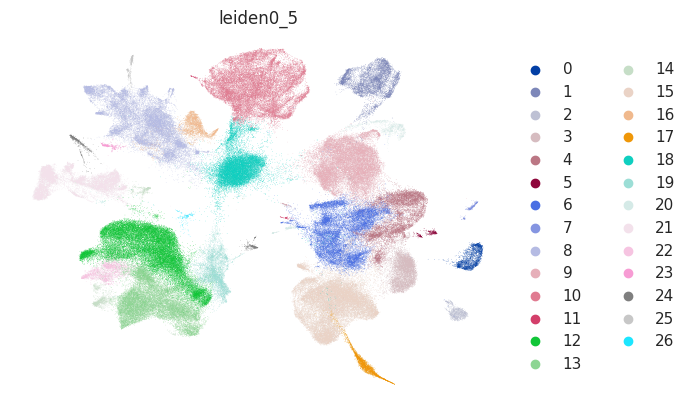

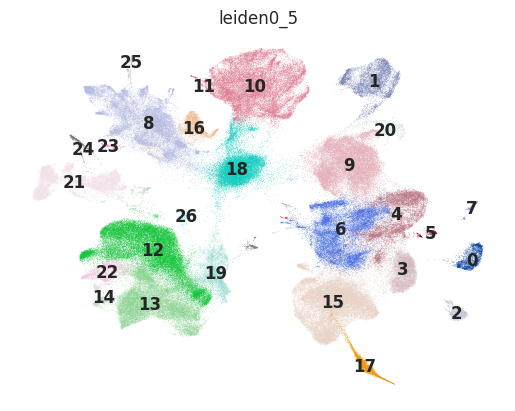

In [11]:
sc.pl.umap(adata, neighbors_key='N_scVI', color='leiden0_5', frameon=False, save='res0_5.png')
sc.pl.umap(adata, neighbors_key='N_scVI', color='leiden0_5', legend_loc="on data", frameon=False, save='res0_5_labeled.png')

In [12]:
# Annotate at resolution 0.5 to separate out RBCs
leiden_key = 'leiden0_5'
leiden_map = {
    "0" : "Tumor",
    "1" : "Pericyte",
    "2" : "Tumor",
    "3" : "Tumor",
    "4" : "Tumor",
    "5" : "Tumor",
    "6" : "Tumor",
    "7" : "Tumor", # a little indeterminate
    "8" : "Myeloid",
    "9" : "Tumor",
    "10" : "Endothelial",
    "11" : "Endothelial",
    "12" : "T_and_NK",
    "13" : "T_and_NK",
    "14" : "T_and_NK", # Proliferating
    "15" : "Tumor",
    "16" : "Myeloid",
    "17" : "Tumor", # Neuronal
    "18" : "Low_quality",
    "19" : "T_and_NK", # Immune
    "20" : "Fibroblast",
    "21" : "B",
    "22" : "T_and_NK",
    "23" : "DC", # Immune
    "24" : "Mast",
    "25" : "Neutrophil",
    "26" : "RBC",
}

adata.obs['coarse_celltype'] = adata.obs[leiden_key].map(leiden_map)

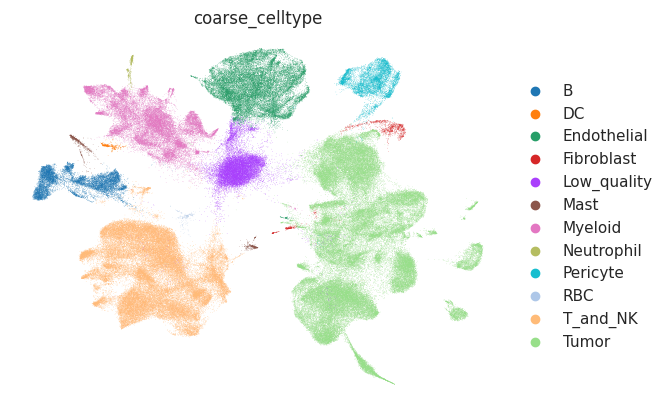

In [13]:
sc.pl.umap(adata, neighbors_key='N_scVI', 
           color=['coarse_celltype'], 
           frameon=False, save='coarse_celltype.png')

# Smooth qc metrics by calculating the median value across a given cluster and plotting that

In [14]:
qc = ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt',]
for metric in qc:
    str_metric = 'median_' + metric
    adata.obs[str_metric] = adata.obs.groupby(leiden_key, observed=True)[metric].transform('median')
print(adata.obs)

                               batch    sample  n_counts  n_genes_by_counts  \
CCTGTTGGTTCGATTG-1_Batch01   Batch01  Sample04     98818              10687   
GAAACCTTCCTGGGTG-1_Batch01   Batch01  Sample03     91055               9889   
CAGGCCAAGCCGCACT-1_Batch01   Batch01  Sample03     90132              10561   
AGCTCAACACGTATAC-1_Batch01   Batch01  Sample03     89624              10261   
TCATACTAGTCTGCGC-1_Batch01   Batch01  Sample04     85410              10525   
...                              ...       ...       ...                ...   
GTGGCAGCAGTGGCGA-1_Sample23  Batch22  Sample23       159                116   
AGTAAGGGTGGTTAGT-1_Sample23  Batch22  Sample23       181                102   
AGCGAATAGATGTGAA-1_Sample23  Batch22  Sample23       146                100   
AACAGAGGTCCAGATG-1_Sample23  Batch22  Sample23       157                128   
CTAGTTACAAGCTTCG-1_Sample23  Batch22  Sample23       155                112   

                             log1p_n_genes_by_count

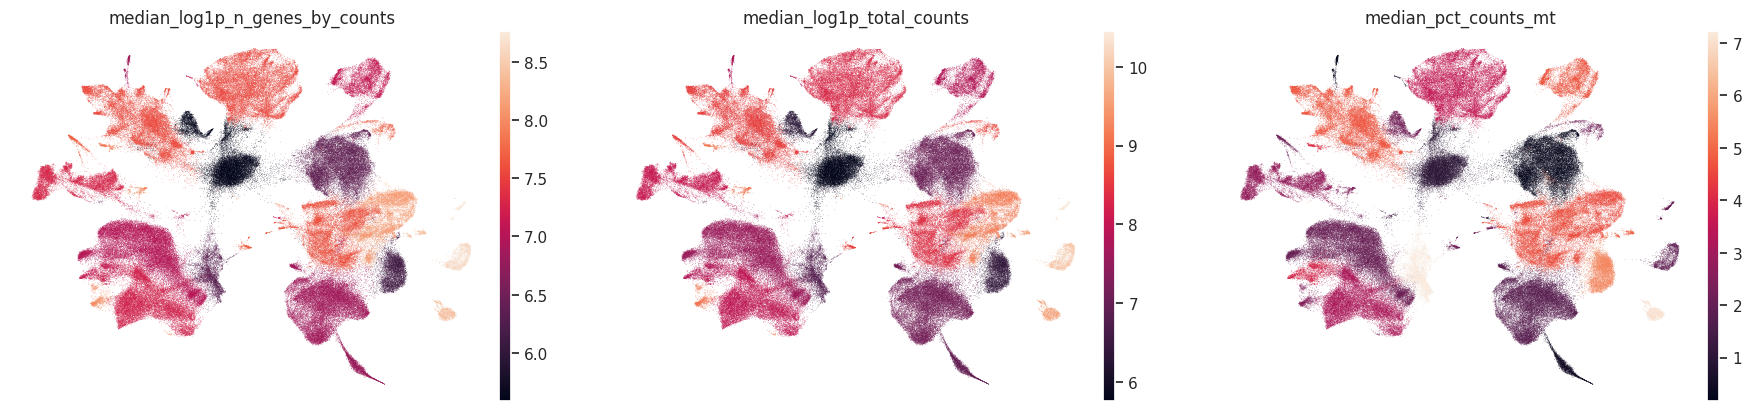

In [15]:
sc.pl.umap(adata, neighbors_key='N_scVI', 
           color=['median_log1p_n_genes_by_counts', 'median_log1p_total_counts', 'median_pct_counts_mt',], 
           frameon=False, save='qc_median_res0_5.png')

In [16]:
median_genes = adata.obs.groupby(leiden_key, observed=True)['median_log1p_n_genes_by_counts'].unique().reset_index().astype(float)
median_genes[leiden_key] = median_genes[leiden_key].astype(int)
median_genes

,leiden0_5,median_log1p_n_genes_by_counts
0,0,8.608860
1,1,7.136483
2,2,8.382861
3,3,6.146329
4,4,8.109826
5,5,8.401782
6,6,7.601902
7,7,8.760296
8,8,7.564238
9,9,6.378426


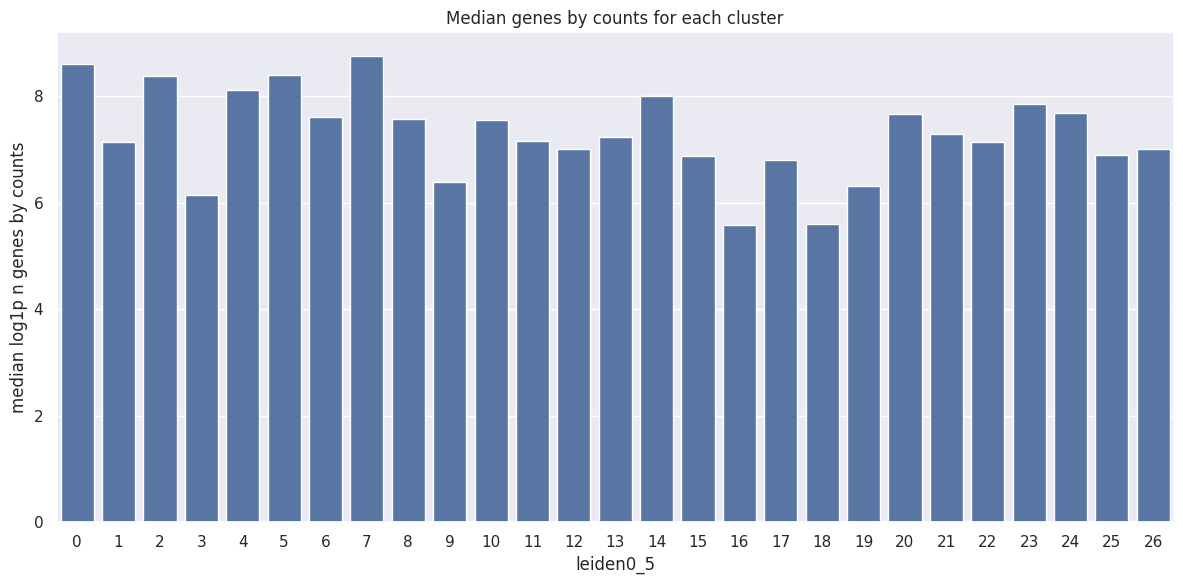

In [17]:
# Create a bar plot for genes by counts
plt.figure(figsize=(12, 6))
sns.barplot(x=leiden_key, y='median_log1p_n_genes_by_counts', data=median_genes)
plt.title('Median genes by counts for each cluster')
plt.ylabel('median log1p n genes by counts')
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig('median_log1p_n_genes_by_counts_barplot.png')
plt.show()

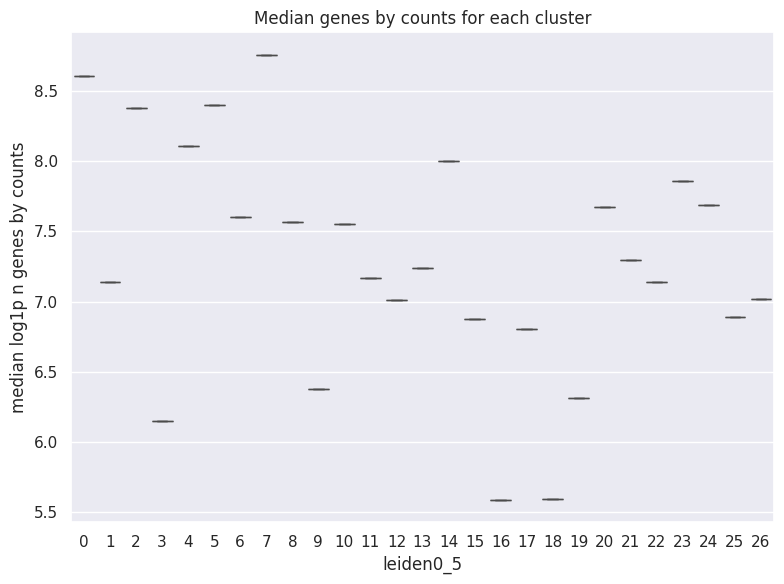

In [18]:
# Create a box plot for genes by counts
plt.figure(figsize=(8, 6))
sns.boxplot(x=leiden_key, y='median_log1p_n_genes_by_counts', data=median_genes)
plt.title('Median genes by counts for each cluster')
plt.ylabel('median log1p n genes by counts')
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig('median_log1p_n_genes_by_counts_boxplot.png')
plt.show()

In [19]:
median_counts = adata.obs.groupby(leiden_key, observed=True)['median_log1p_total_counts'].unique().reset_index().astype(float)
median_counts[leiden_key] = median_genes[leiden_key].astype(int)
median_counts

,leiden0_5,median_log1p_total_counts
0,0,10.003785
1,1,7.864804
2,2,9.574219
3,3,6.408529
4,4,9.171807
5,5,9.607236
6,6,8.403464
7,7,10.447032
8,8,8.570355
9,9,7.052721


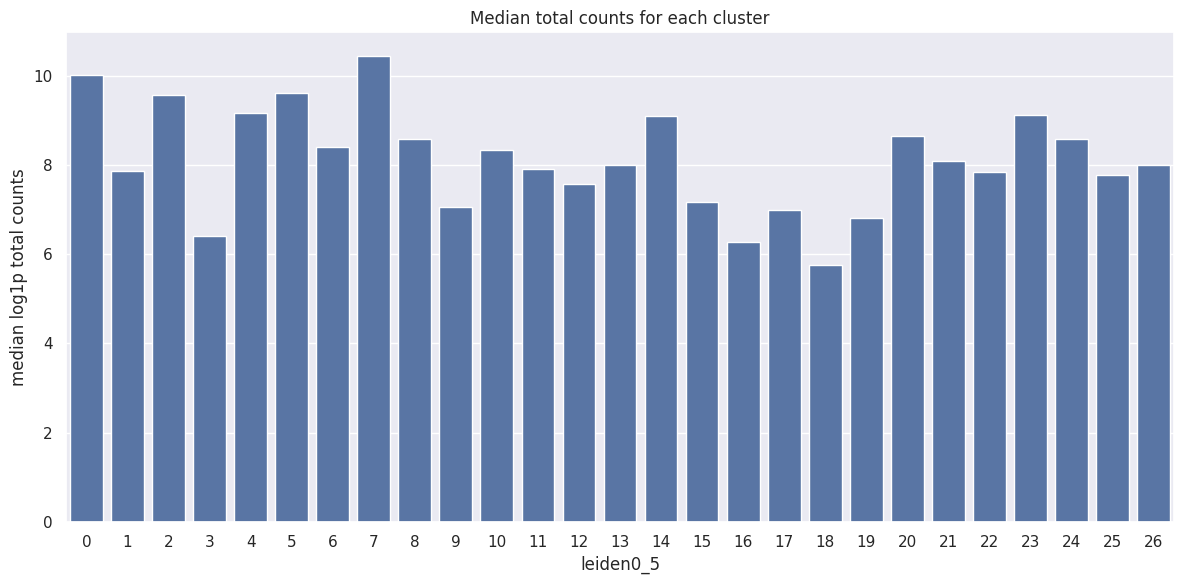

In [20]:
# Create a bar plot for counts
plt.figure(figsize=(12, 6))
sns.barplot(x=leiden_key, y='median_log1p_total_counts', data=median_counts)
plt.title('Median total counts for each cluster')
plt.ylabel('median log1p total counts')
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig('median_log1p_total_counts_barplot.png')
plt.show()

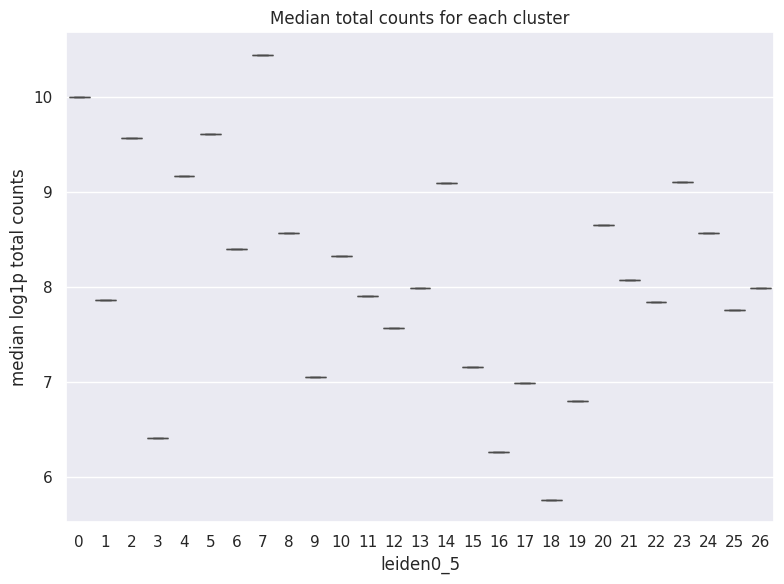

In [21]:
# Create a box plot for counts
plt.figure(figsize=(8, 6))
sns.boxplot(x=leiden_key, y='median_log1p_total_counts', data=median_counts)
plt.title('Median total counts for each cluster')
plt.ylabel('median log1p total counts')
plt.tight_layout() # Adjust layout to prevent clipping
plt.savefig('median_log1p_total_counts_boxplot.png')
plt.show()

In [22]:
median_pct_mt = adata.obs.groupby(leiden_key, observed=True)['median_pct_counts_mt'].unique().reset_index().astype(float)
median_pct_mt[leiden_key] = median_pct_mt[leiden_key].astype(int)
median_pct_mt

,leiden0_5,median_pct_counts_mt
0,0,1.950461
1,1,4.706524
2,2,7.018387
3,3,5.438066
4,4,4.562565
5,5,4.874075
6,6,4.620767
7,7,2.015327
8,8,4.728706
9,9,0.284455


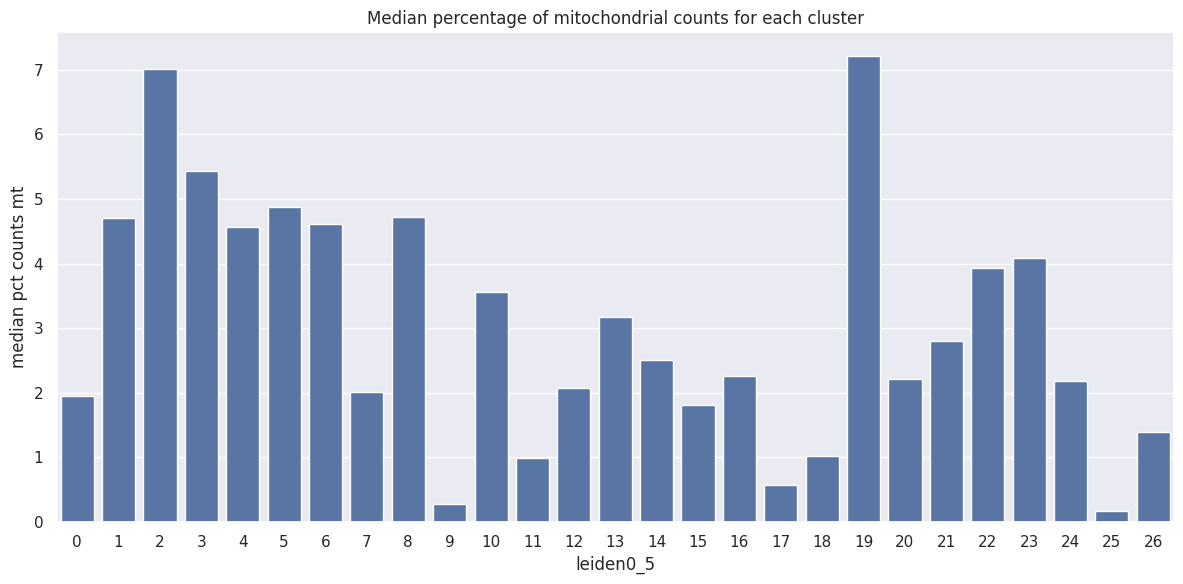

In [23]:
# Create a bar plot for pct_mt
plt.figure(figsize=(12, 6))
sns.barplot(x=leiden_key, y='median_pct_counts_mt', data=median_pct_mt)
plt.title('Median percentage of mitochondrial counts for each cluster')
plt.ylabel('median pct counts mt')
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig('median_pct_counts_mt_barplot.png')
plt.show()

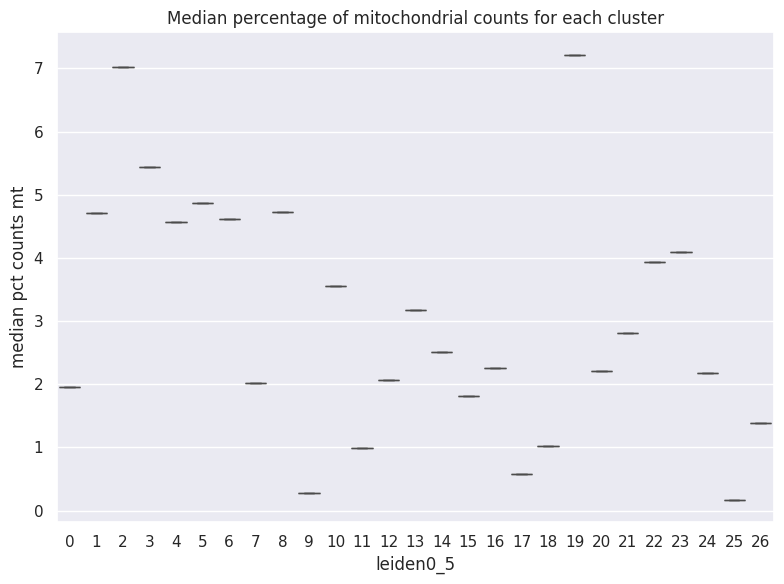

In [24]:
# Create a box plot for pct mt
plt.figure(figsize=(8, 6))
sns.boxplot(x=leiden_key, y='median_pct_counts_mt', data=median_pct_mt)
plt.title('Median percentage of mitochondrial counts for each cluster')
plt.ylabel('median pct counts mt')
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig('median_pct_counts_mt_boxplot.png')
plt.show()

# Remove only low-quality cells and RBCs

In [25]:
adata = adata[~adata.obs['coarse_celltype'].isin(["RBC", "Low_quality"])].copy()
print(adata)

AnnData object with n_obs × n_vars = 223655 × 2000
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score', '_scvi_batch', '_scvi_labels', 'leiden0_1', '_scvi_raw_norm_scaling', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'coarse_celltype', 'median_log1p_n_genes_by_counts', 'median_log1p_total_counts', 'median_pct_counts_mt'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'N_scVI', 'X_pca', '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden

In [27]:
# reload ULMS data (preprocessed anndatas) in order to get the raw counts of all genes
raw_adata = sc.read_h5ad('objects/ulms_raw.h5ad')
print(raw_adata)

raw_adata = raw_adata[adata.obs.index].copy()
print(raw_adata)

AnnData object with n_obs × n_vars = 239879 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score'
AnnData object with n_obs × n_vars = 223655 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score'


In [28]:
raw_adata.write_h5ad(PROJECT_DIR / 'objects/ulms_raw_afterqc_noRBC.h5ad')